# DNN Lab 03: Regularization Techniques & Hyperparameter Tuning

## PyTorch + GPU + MNIST CSV

### Objectives
By the end of this lab, you will be able to:

- Build a complete DNN classification pipeline in PyTorch.
- Use GPU acceleration when CUDA is available.
- Understand overfitting and validation-based model selection.
- Implement L1 regularization, L2 regularization (weight decay), Dropout, Batch Normalization, and Early Stopping.
- Compare regularization techniques using the same dataset and task.
- Understand Grid Search, Random Search, and Optuna.
- Use Optuna to tune a PyTorch DNN.
- Evaluate the final model on an untouched test set.

### Dataset format

The CSV file should contain:

`label, pixel_0, pixel_1, ..., pixel_783`

There are 785 columns in total:
- 1 target column: `label`
- 784 input features: `pixel_0` to `pixel_783`

> **Important:** The test set is used only once for final evaluation. Hyperparameters are selected using the validation set.

## Lab Roadmap

```text
MNIST CSV
   ↓
Data inspection
   ↓
Train / Validation / Test split
   ↓
Normalization
   ↓
PyTorch Dataset + DataLoader
   ↓
Baseline MLP
   ↓
Optimized GPU training loop
   ↓
L1
   ↓
L2 / Weight Decay
   ↓
Dropout
   ↓
Batch Normalization
   ↓
Early Stopping
   ↓
Compare experiments
   ↓
Optuna
   ↓
Final model
   ↓
Test evaluation + confusion matrix
```

## 1. Imports

In [1]:
import os
import random
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


#### GPU Configuration

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("CUDA is not available. Training will use CPU.")

Device: cpu
CUDA is not available. Training will use CPU.


Install Optuna

Run this cell once if Optuna is not already installed.

If your environment does not allow `pip` inside notebooks, install Optuna separately using:

```bash
pip install optuna
```

In [3]:
# Uncomment and run only if Optuna is not installed.
#!pip install optuna

In [4]:
import optuna
print("Optuna version:", optuna.__version__)

Optuna version: 5.0.0


## 2. Load the MNIST CSV

Change `CSV_PATH` to the location/name of your dataset.

Example:

```python
CSV_PATH = "mnist.csv"
```

If your file has a different name, change it here only.

In [5]:
CSV_PATH = "train.csv"   #

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Inspect the Dataset

In [6]:
print("Columns:", len(df.columns))
print("First columns:", df.columns[:10].tolist())
print("Last columns:", df.columns[-5:].tolist())

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nLabel distribution:")
display(df["label"].value_counts().sort_index())

Columns: 785
First columns: ['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8']
Last columns: ['pixel779', 'pixel780', 'pixel781', 'pixel782', 'pixel783']

Missing values: 0
Duplicate rows: 0

Label distribution:


label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

#### Separate Features and Labels

The first column is the target:

- `label` → digit class 0–9
- `pixel_0 ... pixel_783` → 784 input features

In [7]:
X = df.drop(columns=["label"]).values
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

assert X.shape[1] == 784, "Expected exactly 784 pixel features."

X shape: (42000, 784)
y shape: (42000,)


#### Check Pixel Range

In [8]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0
Maximum pixel value: 255


#### Visualize Some Original Digits

Each row contains 784 pixels. We reshape the 784 values into:

`28 × 28`

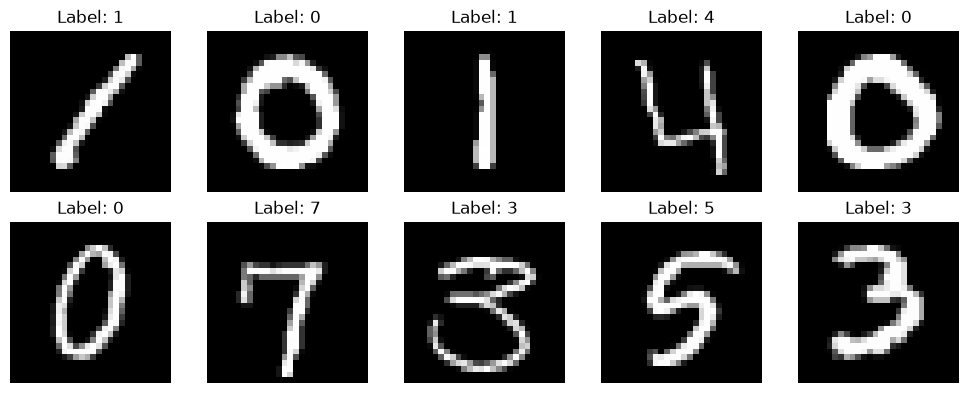

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Train / Validation / Test Split

We use:

- **80% training**
- **10% validation**
- **10% test**

`stratify=y` keeps the class distribution approximately balanced across splits.

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.40,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (33600, 784) (33600,)
Validation: (5040, 784) (5040,)
Test: (3360, 784) (3360,)


## 4. Normalize Pixel Values

MNIST pixels are usually in `[0, 255]`.

We scale them to `[0, 1]`:

\[
x_{normalized} = \frac{x}{255}
\]

This generally makes neural-network optimization more stable.

In [12]:
X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

print("Train range:", X_train.min(), "to", X_train.max())

Train range: 0.0 to 1.0


## 4. PyTorch Dataset

In [13]:
class MNISTCSVDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = MNISTCSVDataset(X_train, y_train)
val_dataset   = MNISTCSVDataset(X_val, y_val)
test_dataset  = MNISTCSVDataset(X_test, y_test)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 33600
Validation samples: 5040
Test samples: 3360


In [17]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

#### DataLoaders

`pin_memory=True` can improve host-to-GPU transfer when CUDA is being used.

`non_blocking=True` will be used during tensor transfer to the GPU.

In [18]:
BATCH_SIZE = 128

loader_kwargs = {
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available()
}

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 263
Validation batches: 40
Test batches: 27


#### Inspect One Batch

In [19]:
X_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", X_batch.shape)
print("Label batch shape:", y_batch.shape)
print("Input dtype:", X_batch.dtype)
print("Label dtype:", y_batch.dtype)

Input batch shape: torch.Size([128, 784])
Label batch shape: torch.Size([128])
Input dtype: torch.float32
Label dtype: torch.int64


## 5. PyTorch DNN Modeling

# Part A: Baseline DNN

We first create a model **without explicit regularization**.

Architecture:

```text
784
 ↓
512
 ↓
256
 ↓
128
 ↓
10
```

The purpose is to establish a baseline before adding regularization.

In [20]:
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


baseline_model = BaselineMLP().to(device)

print(baseline_model)
from torchinfo import summary
summary(baseline_model)

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


Layer (type:depth-idx)                   Param #
BaselineMLP                              --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       401,920
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       131,328
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       32,896
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       1,290
Total params: 567,434
Trainable params: 567,434
Non-trainable params: 0

### Optimized Training and Evaluation Functions

Important steps:

- `model.train()` → training mode
- `model.eval()` → evaluation mode
- `torch.no_grad()` → no gradient calculation during validation
- `zero_grad(set_to_none=True)` → efficient gradient reset
- `non_blocking=True` → efficient CPU → GPU transfer when pinned memory is enabled

In [21]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    regularization=None,
    reg_lambda=0.0
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )
        y_batch = y_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        if regularization == "l1":
            l1 = sum(
                p.abs().sum()
                for p in model.parameters()
                if p.requires_grad
            )
            loss = loss + reg_lambda * l1

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )
        y_batch = y_batch.to(
            device,
            non_blocking=True
        )

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        running_loss += loss.item() * X_batch.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

### General Training Function

This function will be reused for every regularization experiment.

That is important scientifically: **we keep the training pipeline consistent and change only the regularization method.**

In [22]:
def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    regularization=None,
    reg_lambda=0.0,
    early_stopping=False,
    patience=3,
    verbose=True
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            regularization=regularization,
            reg_lambda=reg_lambda
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

        if early_stopping:

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)

    return history

### Plot Training History

In [23]:
def plot_history(history, title):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " — Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Experiment 1: Baseline

No L1, no weight decay, no Dropout, no BatchNorm, and no early stopping.

This gives us a reference point.

In [24]:
EPOCHS = 15
LEARNING_RATE = 1e-3

model_baseline = BaselineMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_baseline.parameters(),
    lr=LEARNING_RATE
)

start = time.time()

history_baseline = fit_model(
    model_baseline,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=EPOCHS
)

print(f"Training time: {time.time() - start:.2f} seconds")

Epoch 01/15 | Train Loss: 0.4200 | Train Acc: 0.8767 | Val Loss: 0.1871 | Val Acc: 0.9435
Epoch 02/15 | Train Loss: 0.1429 | Train Acc: 0.9579 | Val Loss: 0.1312 | Val Acc: 0.9611
Epoch 03/15 | Train Loss: 0.0911 | Train Acc: 0.9724 | Val Loss: 0.1087 | Val Acc: 0.9673
Epoch 04/15 | Train Loss: 0.0645 | Train Acc: 0.9793 | Val Loss: 0.1175 | Val Acc: 0.9643
Epoch 05/15 | Train Loss: 0.0476 | Train Acc: 0.9854 | Val Loss: 0.0912 | Val Acc: 0.9756
Epoch 06/15 | Train Loss: 0.0373 | Train Acc: 0.9879 | Val Loss: 0.1080 | Val Acc: 0.9704
Epoch 07/15 | Train Loss: 0.0286 | Train Acc: 0.9907 | Val Loss: 0.1245 | Val Acc: 0.9698
Epoch 08/15 | Train Loss: 0.0213 | Train Acc: 0.9931 | Val Loss: 0.1063 | Val Acc: 0.9762
Epoch 09/15 | Train Loss: 0.0178 | Train Acc: 0.9939 | Val Loss: 0.1164 | Val Acc: 0.9732
Epoch 10/15 | Train Loss: 0.0174 | Train Acc: 0.9942 | Val Loss: 0.1073 | Val Acc: 0.9782
Epoch 11/15 | Train Loss: 0.0140 | Train Acc: 0.9957 | Val Loss: 0.1086 | Val Acc: 0.9770
Epoch 12/1

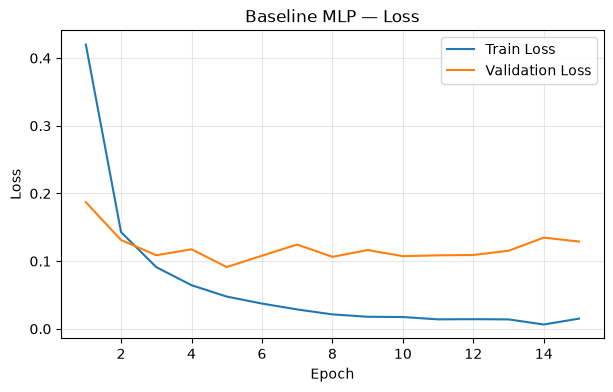

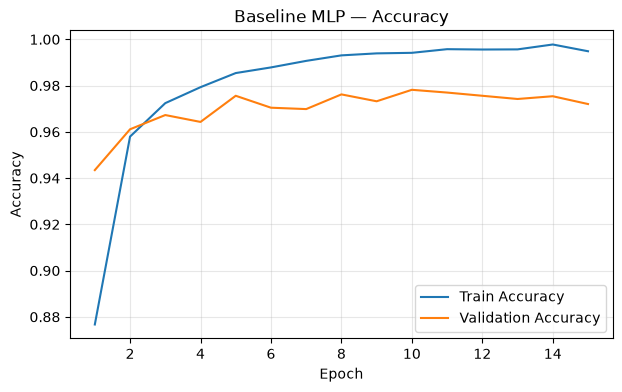

In [25]:
plot_history(history_baseline, "Baseline MLP")

## Baseline Observation

Look at the gap between:

- training accuracy
- validation accuracy

A large and increasing gap is evidence of overfitting.

**Question:** At which epoch does the model begin showing signs of overfitting?

# Part B: L1 Regularization

L1 adds a penalty:

$$
L_{total} = L_{CE} + \lambda \sum_i |w_i|
$$

L1 tends to encourage small or zero-valued weights.

We use the same model architecture.

In [26]:
L1_LAMBDA = 1e-6

model_l1 = BaselineMLP().to(device)

optimizer_l1 = torch.optim.Adam(
    model_l1.parameters(),
    lr=LEARNING_RATE
)

history_l1 = fit_model(
    model_l1,
    train_loader,
    val_loader,
    criterion,
    optimizer_l1,
    device,
    epochs=EPOCHS,
    regularization="l1",
    reg_lambda=L1_LAMBDA
)

Epoch 01/15 | Train Loss: 0.4293 | Train Acc: 0.8792 | Val Loss: 0.2037 | Val Acc: 0.9403
Epoch 02/15 | Train Loss: 0.1563 | Train Acc: 0.9556 | Val Loss: 0.1479 | Val Acc: 0.9567
Epoch 03/15 | Train Loss: 0.1039 | Train Acc: 0.9723 | Val Loss: 0.1224 | Val Acc: 0.9649
Epoch 04/15 | Train Loss: 0.0786 | Train Acc: 0.9796 | Val Loss: 0.1059 | Val Acc: 0.9698
Epoch 05/15 | Train Loss: 0.0611 | Train Acc: 0.9849 | Val Loss: 0.0963 | Val Acc: 0.9752
Epoch 06/15 | Train Loss: 0.0533 | Train Acc: 0.9874 | Val Loss: 0.1003 | Val Acc: 0.9714
Epoch 07/15 | Train Loss: 0.0439 | Train Acc: 0.9907 | Val Loss: 0.1109 | Val Acc: 0.9702
Epoch 08/15 | Train Loss: 0.0416 | Train Acc: 0.9910 | Val Loss: 0.0914 | Val Acc: 0.9766
Epoch 09/15 | Train Loss: 0.0330 | Train Acc: 0.9943 | Val Loss: 0.1038 | Val Acc: 0.9744
Epoch 10/15 | Train Loss: 0.0312 | Train Acc: 0.9947 | Val Loss: 0.1000 | Val Acc: 0.9758
Epoch 11/15 | Train Loss: 0.0318 | Train Acc: 0.9952 | Val Loss: 0.1516 | Val Acc: 0.9613
Epoch 12/1

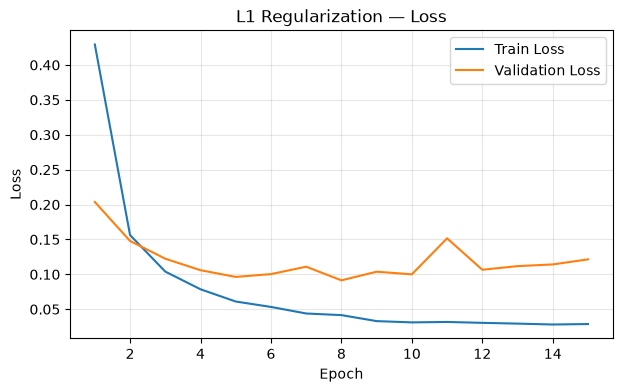

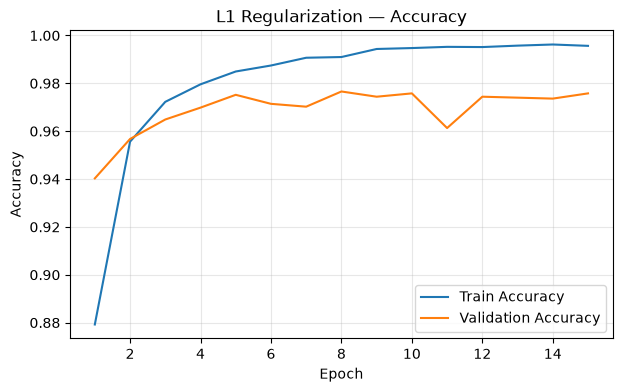

In [27]:
plot_history(history_l1, "L1 Regularization")

### L1 Experiment Questions

1. Did training accuracy decrease?
2. Did the train/validation gap change?
3. What happens if `L1_LAMBDA` is increased?

# Part C: L2 Regularization / Weight Decay

A common practical way to apply L2-style regularization is through optimizer `weight_decay`.

Conceptually:

$$
L_{total} = L_{CE} + \lambda \sum_i w_i^2
$$

In [28]:
WEIGHT_DECAY = 1e-4

model_l2 = BaselineMLP().to(device)

optimizer_l2 = torch.optim.AdamW(
    model_l2.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

history_l2 = fit_model(
    model_l2,
    train_loader,
    val_loader,
    criterion,
    optimizer_l2,
    device,
    epochs=EPOCHS
)

Epoch 01/15 | Train Loss: 0.4210 | Train Acc: 0.8785 | Val Loss: 0.1995 | Val Acc: 0.9411
Epoch 02/15 | Train Loss: 0.1476 | Train Acc: 0.9557 | Val Loss: 0.1308 | Val Acc: 0.9599
Epoch 03/15 | Train Loss: 0.0944 | Train Acc: 0.9704 | Val Loss: 0.1091 | Val Acc: 0.9690
Epoch 04/15 | Train Loss: 0.0643 | Train Acc: 0.9804 | Val Loss: 0.1055 | Val Acc: 0.9700
Epoch 05/15 | Train Loss: 0.0511 | Train Acc: 0.9836 | Val Loss: 0.0949 | Val Acc: 0.9726
Epoch 06/15 | Train Loss: 0.0364 | Train Acc: 0.9889 | Val Loss: 0.1022 | Val Acc: 0.9714
Epoch 07/15 | Train Loss: 0.0263 | Train Acc: 0.9916 | Val Loss: 0.1123 | Val Acc: 0.9720
Epoch 08/15 | Train Loss: 0.0249 | Train Acc: 0.9921 | Val Loss: 0.0989 | Val Acc: 0.9738
Epoch 09/15 | Train Loss: 0.0185 | Train Acc: 0.9941 | Val Loss: 0.1150 | Val Acc: 0.9716
Epoch 10/15 | Train Loss: 0.0228 | Train Acc: 0.9926 | Val Loss: 0.1426 | Val Acc: 0.9687
Epoch 11/15 | Train Loss: 0.0137 | Train Acc: 0.9954 | Val Loss: 0.1156 | Val Acc: 0.9738
Epoch 12/1

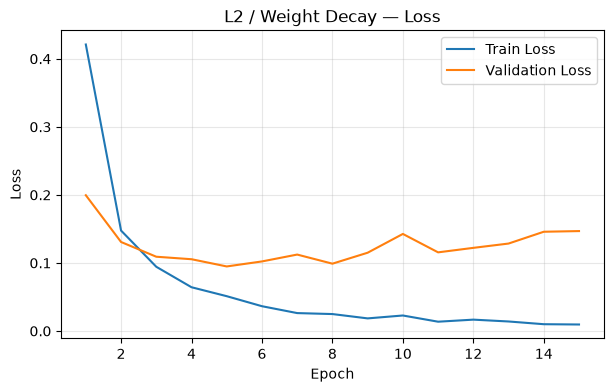

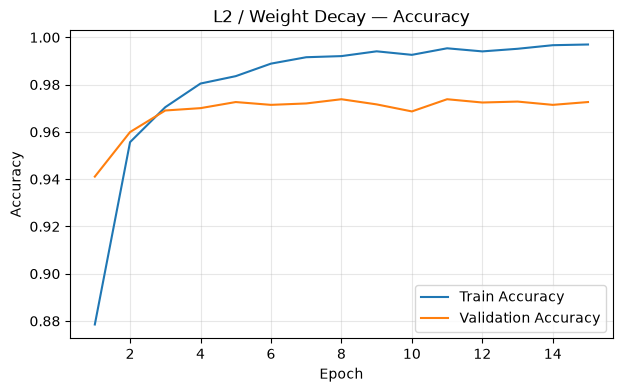

In [29]:
plot_history(history_l2, "L2 / Weight Decay")

### Why AdamW?

For this lab we use `AdamW`, which implements decoupled weight decay. This lets students see weight decay as a hyperparameter without manually adding an L2 term to the loss.

**Question:** What happens if `weight_decay` is increased from `1e-4` to `1e-3`?

# Part D: Dropout

Dropout randomly disables units during training.

Example:

```text
Before Dropout:

● ● ● ● ● ● ●

After Dropout:

● ○ ● ● ○ ● ○
```

The model therefore cannot depend too heavily on a small set of neurons.

In [30]:
class DropoutMLP(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


DROPOUT_RATE = 0.3

model_dropout = DropoutMLP(DROPOUT_RATE).to(device)

optimizer_dropout = torch.optim.Adam(
    model_dropout.parameters(),
    lr=LEARNING_RATE
)

history_dropout = fit_model(
    model_dropout,
    train_loader,
    val_loader,
    criterion,
    optimizer_dropout,
    device,
    epochs=EPOCHS
)

Epoch 01/15 | Train Loss: 0.5273 | Train Acc: 0.8359 | Val Loss: 0.1974 | Val Acc: 0.9397
Epoch 02/15 | Train Loss: 0.1897 | Train Acc: 0.9440 | Val Loss: 0.1351 | Val Acc: 0.9587
Epoch 03/15 | Train Loss: 0.1351 | Train Acc: 0.9593 | Val Loss: 0.1219 | Val Acc: 0.9633
Epoch 04/15 | Train Loss: 0.1038 | Train Acc: 0.9690 | Val Loss: 0.1058 | Val Acc: 0.9675
Epoch 05/15 | Train Loss: 0.0873 | Train Acc: 0.9738 | Val Loss: 0.0945 | Val Acc: 0.9726
Epoch 06/15 | Train Loss: 0.0751 | Train Acc: 0.9774 | Val Loss: 0.0981 | Val Acc: 0.9720
Epoch 07/15 | Train Loss: 0.0652 | Train Acc: 0.9802 | Val Loss: 0.0888 | Val Acc: 0.9752
Epoch 08/15 | Train Loss: 0.0602 | Train Acc: 0.9814 | Val Loss: 0.0954 | Val Acc: 0.9748
Epoch 09/15 | Train Loss: 0.0498 | Train Acc: 0.9837 | Val Loss: 0.0938 | Val Acc: 0.9744
Epoch 10/15 | Train Loss: 0.0461 | Train Acc: 0.9856 | Val Loss: 0.0837 | Val Acc: 0.9768
Epoch 11/15 | Train Loss: 0.0409 | Train Acc: 0.9873 | Val Loss: 0.0985 | Val Acc: 0.9734
Epoch 12/1

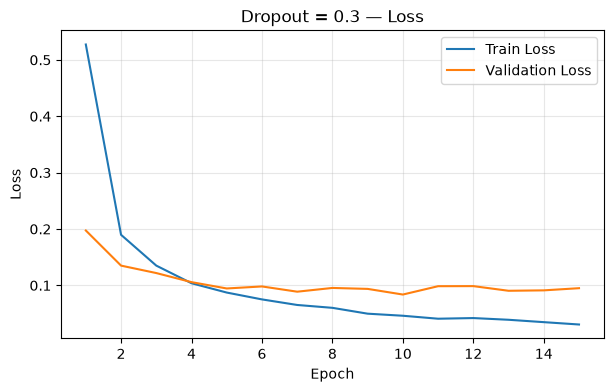

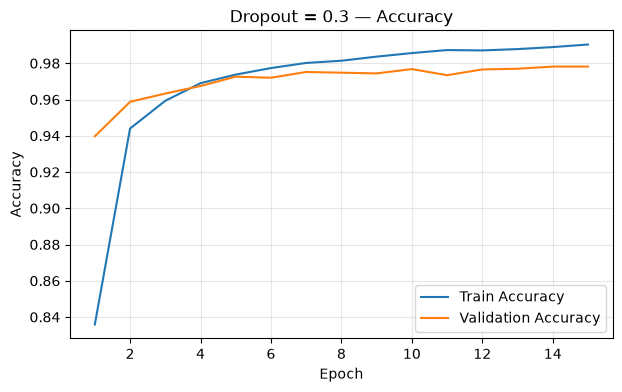

In [31]:
plot_history(history_dropout, f"Dropout = {DROPOUT_RATE}")

### Dropout Experiment

Try:

```python
DROPOUT_RATE = 0.1
DROPOUT_RATE = 0.3
DROPOUT_RATE = 0.5
```

Compare validation accuracy.

Remember: very strong regularization can also cause underfitting.

# Part E: Batch Normalization

BatchNorm normalizes intermediate activations during training
For your DNN lab, I would present it as:

$$ \boxed{z=Wx+b} $$

↓

Batch mean
$$ \boxed{\mu_B=\frac{1}{m}\sum_{i=1}^{m}z_i} $$

↓

Batch variance
$$ \boxed{ \sigma_B^2= \frac{1}{m}\sum_{i=1}^{m}(z_i-\mu_B)^2 } $$

↓

Normalize
$$ \boxed{ \hat z_i= \frac{z_i-\mu_B} {\sqrt{\sigma_B^2+\epsilon}} } $$

↓

Scale and shift
$$ \boxed{ y_i=\gamma\hat z_i+\beta } $$

↓

Activation
$$ \boxed{ a_i=\max(0,y_i) } $$

So the complete pipeline is:

$$ \boxed{ x \rightarrow Wx+b \rightarrow BN \rightarrow ReLU \rightarrow a } $$

Then gradient descent updates \(\gamma\):

$$ \boxed{ \gamma_{\text{new}} = \gamma_{\text{old}} - \eta \frac{\partial L}{\partial\gamma} } $$

where \(\eta\) is the learning rate.

And gradient descent Beta:

$$ \boxed{ \beta_{\text{new}} = \beta_{\text{old}} - \eta \frac{\partial L}{\partial\beta} } $$

It is **not identical to Dropout or L2**, although it can have a regularizing effect.

In [32]:
class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


model_bn = BatchNormMLP().to(device)
print("BatchNorm \n",model_bn)

print("\nTrainable parameters:",

      sum(p.numel() for p in model_bn.parameters() if p.requires_grad))

BatchNorm 
 BatchNormMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 569226


                 BATCH NORMALIZATION
                         │
          ┌──────────────┴──────────────┐
          │                             │
    Learnable parameters          Running statistics
          │                             │
      γ and β                       mean & variance
          │                             │
   
   Backpropagation                  Batch statistics
   
          │                             │
   
     Gradients                    momentum = 0.1
          
          │                             │
   Learning rate                        
          
          │                             │
          
          ▼                             ▼
     
     γ and β update             running stats update

     

In [33]:
from torchinfo import summary
summary(model_bn)

Layer (type:depth-idx)                   Param #
BatchNormMLP                             --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       401,920
│    └─BatchNorm1d: 2-2                  1,024
│    └─ReLU: 2-3                         --
│    └─Linear: 2-4                       131,328
│    └─BatchNorm1d: 2-5                  512
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       32,896
│    └─BatchNorm1d: 2-8                  256
│    └─ReLU: 2-9                         --
│    └─Linear: 2-10                      1,290
Total params: 569,226
Trainable params: 569,226
Non-trainable params: 0

In [34]:
optimizer_bn = torch.optim.Adam(
    model_bn.parameters(),
    lr=LEARNING_RATE
)

history_bn = fit_model(
    model_bn,
    train_loader,
    val_loader,
    criterion,
    optimizer_bn,
    device,
    epochs=EPOCHS
)

Epoch 01/15 | Train Loss: 0.2562 | Train Acc: 0.9343 | Val Loss: 0.1203 | Val Acc: 0.9641
Epoch 02/15 | Train Loss: 0.0899 | Train Acc: 0.9723 | Val Loss: 0.1012 | Val Acc: 0.9700
Epoch 03/15 | Train Loss: 0.0586 | Train Acc: 0.9820 | Val Loss: 0.0864 | Val Acc: 0.9730
Epoch 04/15 | Train Loss: 0.0400 | Train Acc: 0.9874 | Val Loss: 0.0872 | Val Acc: 0.9738
Epoch 05/15 | Train Loss: 0.0328 | Train Acc: 0.9895 | Val Loss: 0.0846 | Val Acc: 0.9756
Epoch 06/15 | Train Loss: 0.0229 | Train Acc: 0.9929 | Val Loss: 0.0754 | Val Acc: 0.9788
Epoch 07/15 | Train Loss: 0.0203 | Train Acc: 0.9929 | Val Loss: 0.0778 | Val Acc: 0.9774
Epoch 08/15 | Train Loss: 0.0181 | Train Acc: 0.9943 | Val Loss: 0.0855 | Val Acc: 0.9778
Epoch 09/15 | Train Loss: 0.0184 | Train Acc: 0.9940 | Val Loss: 0.0935 | Val Acc: 0.9748
Epoch 10/15 | Train Loss: 0.0162 | Train Acc: 0.9944 | Val Loss: 0.0953 | Val Acc: 0.9762
Epoch 11/15 | Train Loss: 0.0128 | Train Acc: 0.9956 | Val Loss: 0.0837 | Val Acc: 0.9800
Epoch 12/1

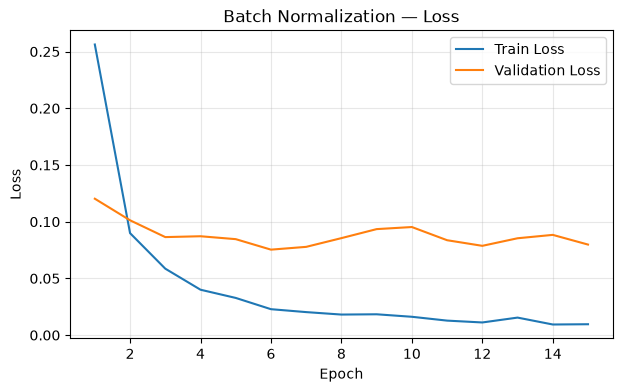

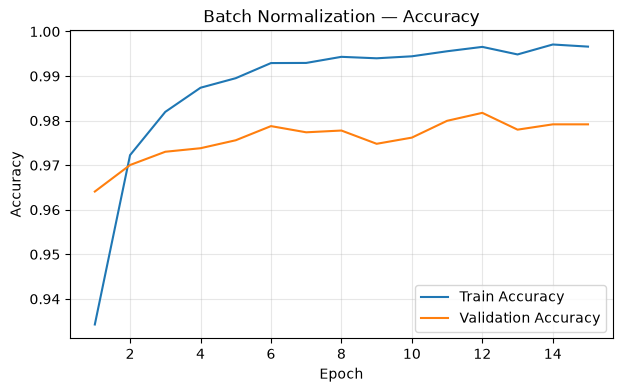

In [35]:
plot_history(history_bn, "Batch Normalization")

# Part F: Early Stopping

Early stopping monitors validation performance.

If validation loss does not improve for a specified number of epochs (`patience`), training stops.

The best model state is restored.

In [36]:
model_early = BaselineMLP().to(device)

optimizer_early = torch.optim.Adam(
    model_early.parameters(),
    lr=LEARNING_RATE
)

history_early = fit_model(
    model_early,
    train_loader,
    val_loader,
    criterion,
    optimizer_early,
    device,
    epochs=30,
    early_stopping=True,
    patience=3
)

Epoch 01/30 | Train Loss: 0.4144 | Train Acc: 0.8798 | Val Loss: 0.1935 | Val Acc: 0.9440
Epoch 02/30 | Train Loss: 0.1443 | Train Acc: 0.9563 | Val Loss: 0.1535 | Val Acc: 0.9530
Epoch 03/30 | Train Loss: 0.0924 | Train Acc: 0.9720 | Val Loss: 0.1164 | Val Acc: 0.9631
Epoch 04/30 | Train Loss: 0.0651 | Train Acc: 0.9801 | Val Loss: 0.1118 | Val Acc: 0.9659
Epoch 05/30 | Train Loss: 0.0452 | Train Acc: 0.9862 | Val Loss: 0.0984 | Val Acc: 0.9702
Epoch 06/30 | Train Loss: 0.0374 | Train Acc: 0.9879 | Val Loss: 0.1074 | Val Acc: 0.9698
Epoch 07/30 | Train Loss: 0.0267 | Train Acc: 0.9914 | Val Loss: 0.1173 | Val Acc: 0.9706
Epoch 08/30 | Train Loss: 0.0245 | Train Acc: 0.9917 | Val Loss: 0.1149 | Val Acc: 0.9712
Early stopping at epoch 8.


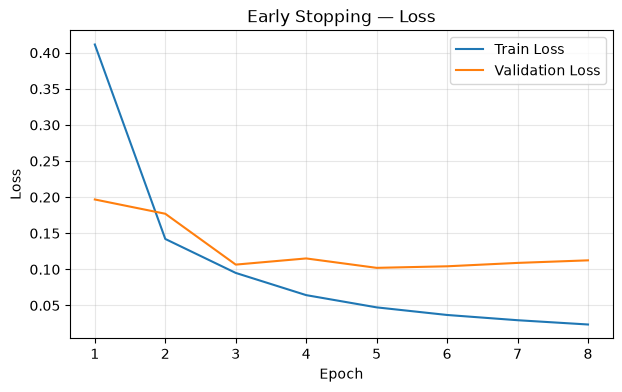

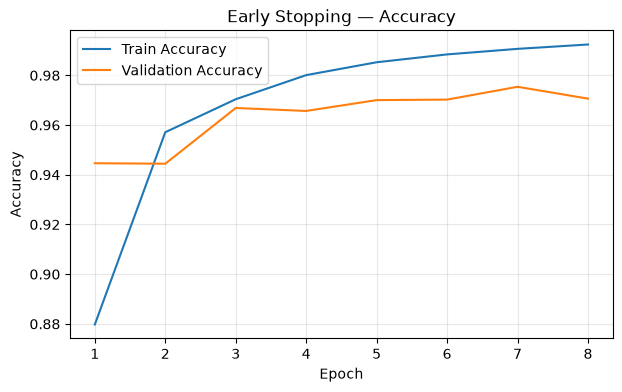

In [35]:
plot_history(history_early, "Early Stopping")

# Part G: Combine Regularization Techniques

Now we create a more flexible model containing:

- BatchNorm
- Dropout
- L2 / weight decay
- Early stopping

In [36]:
class RegularizedMLP(nn.Module):
    def __init__(self, hidden_size=512, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size // 2, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [37]:
model_combined = RegularizedMLP(
    hidden_size=512,
    dropout=0.3
).to(device)

optimizer_combined = torch.optim.AdamW(
    model_combined.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

history_combined = fit_model(
    model_combined,
    train_loader,
    val_loader,
    criterion,
    optimizer_combined,
    device,
    epochs=30,
    early_stopping=True,
    patience=4
)

Epoch 01/30 | Train Loss: 0.3334 | Train Acc: 0.9049 | Val Loss: 0.1257 | Val Acc: 0.9613
Epoch 02/30 | Train Loss: 0.1370 | Train Acc: 0.9561 | Val Loss: 0.1095 | Val Acc: 0.9679
Epoch 03/30 | Train Loss: 0.1056 | Train Acc: 0.9666 | Val Loss: 0.1004 | Val Acc: 0.9710
Epoch 04/30 | Train Loss: 0.0854 | Train Acc: 0.9727 | Val Loss: 0.0885 | Val Acc: 0.9746
Epoch 05/30 | Train Loss: 0.0724 | Train Acc: 0.9758 | Val Loss: 0.0883 | Val Acc: 0.9744
Epoch 06/30 | Train Loss: 0.0658 | Train Acc: 0.9787 | Val Loss: 0.0819 | Val Acc: 0.9756
Epoch 07/30 | Train Loss: 0.0573 | Train Acc: 0.9814 | Val Loss: 0.0778 | Val Acc: 0.9782
Epoch 08/30 | Train Loss: 0.0518 | Train Acc: 0.9823 | Val Loss: 0.0800 | Val Acc: 0.9766
Epoch 09/30 | Train Loss: 0.0444 | Train Acc: 0.9840 | Val Loss: 0.0861 | Val Acc: 0.9762
Epoch 10/30 | Train Loss: 0.0460 | Train Acc: 0.9848 | Val Loss: 0.0870 | Val Acc: 0.9754
Epoch 11/30 | Train Loss: 0.0409 | Train Acc: 0.9857 | Val Loss: 0.0777 | Val Acc: 0.9798
Epoch 12/3

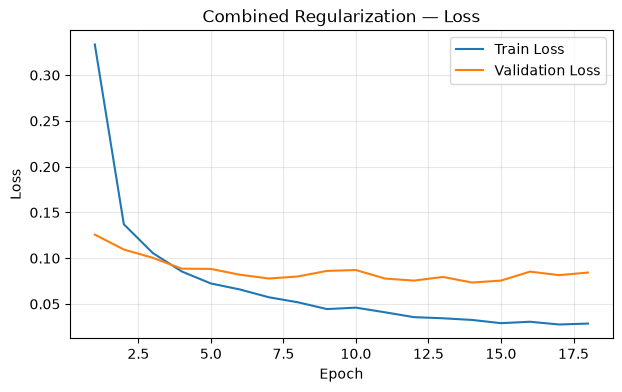

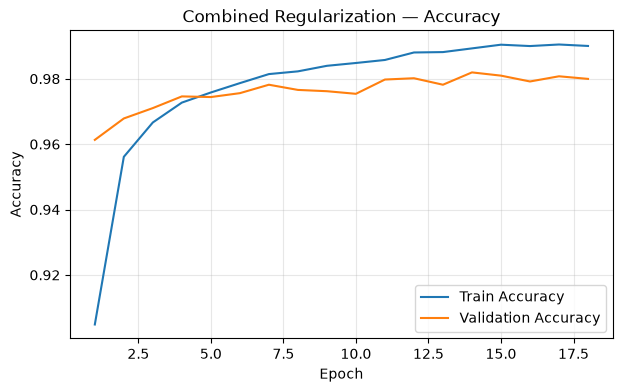

In [38]:
plot_history(history_combined, "Combined Regularization")

# Part H: Compare Regularization Experiments

We compare the best validation accuracy observed by each experiment.

> These results depend on your dataset, random seed, GPU, PyTorch version, and hyperparameters. Do not assume one method will always produce the highest score.

In [39]:
def best_val_accuracy(history):
    return max(history["val_acc"])


comparison = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "L1",
        "L2 / Weight Decay",
        "Dropout",
        "BatchNorm",
        "Early Stopping",
        "Combined"
    ],
    "Best Validation Accuracy": [
        best_val_accuracy(history_baseline),
        best_val_accuracy(history_l1),
        best_val_accuracy(history_l2),
        best_val_accuracy(history_dropout),
        best_val_accuracy(history_bn),
        best_val_accuracy(history_early),
        best_val_accuracy(history_combined)
    ]
})

display(
    comparison.sort_values(
        "Best Validation Accuracy",
        ascending=False
    ).reset_index(drop=True)
)

,Experiment,Best Validation Accuracy
0,Combined,0.981944
1,Dropout,0.979762
2,BatchNorm,0.979167
3,Baseline,0.976389
4,L1,0.975992
5,Early Stopping,0.975397
6,L2 / Weight Decay,0.975198


## Optuna

Optuna is the main hyperparameter optimization exercise.

The optimization loop is:

```text
Optuna
  ↓
Suggest hyperparameters
  ↓
Create PyTorch model
  ↓
Train
  ↓
Validate
  ↓
Report validation score
  ↓
Prune bad trials when appropriate
  ↓
Suggest another configuration
```

We search:

- learning rate
- dropout
- weight decay
- hidden size
- optimizer
- batch size

In [40]:
def make_loaders(batch_size):

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader

## Optuna Objective Function

For demonstration, the tuning budget is intentionally modest.

On a stronger GPU, increase:

- `N_TRIALS`
- `TUNING_EPOCHS`

The validation set is used for optimization. The test set is not touched.

In [41]:
TUNING_EPOCHS = 8

def objective(trial):

    lr = trial.suggest_float(
        "lr",
        1e-4,
        1e-2,
        log=True
    )

    dropout = trial.suggest_float(
        "dropout",
        0.1,
        0.5
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    hidden_size = trial.suggest_categorical(
        "hidden_size",
        [256, 512, 768]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [64, 128, 256]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW"]
    )

    train_loader_t, val_loader_t = make_loaders(
        batch_size
    )

    model = RegularizedMLP(
        hidden_size=hidden_size,
        dropout=dropout
    ).to(device)

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    criterion_t = nn.CrossEntropyLoss()

    best_val_acc = 0.0

    for epoch in range(TUNING_EPOCHS):

        train_one_epoch(
            model,
            train_loader_t,
            criterion_t,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader_t,
            criterion_t,
            device
        )

        best_val_acc = max(
            best_val_acc,
            val_acc
        )

        # Report the current validation result to Optuna.
        trial.report(val_acc, epoch)

        # Prune trials that are not promising.
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_acc

## Run the Optuna Study

In [42]:
N_TRIALS = 20

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
)

start = time.time()

study.optimize(
    objective,
    n_trials=N_TRIALS
)

print(f"Optuna time: {time.time() - start:.2f} seconds")

[I 2026-09-21 11:49:37,444] A new study created in memory with name: no-name-a3a82d1f-2621-4f1f-8b7d-7c769c551dbf
[I 2026-09-21 11:49:59,835] Trial 0 finished with value: 0.9696428571428571 and parameters: {'lr': 0.0005611516415334506, 'dropout': 0.4802857225639665, 'weight_decay': 0.000157029708840554, 'hidden_size': 256, 'batch_size': 128, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.9696428571428571.
[I 2026-09-21 11:51:29,236] Trial 1 finished with value: 0.9748015873015873 and parameters: {'lr': 0.008706020878304856, 'dropout': 0.4329770563201687, 'weight_decay': 4.335281794951567e-06, 'hidden_size': 768, 'batch_size': 64, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.9748015873015873.
[I 2026-09-21 11:51:48,275] Trial 2 finished with value: 0.9753968253968254 and parameters: {'lr': 0.0003839629299804173, 'dropout': 0.2465447373174767, 'weight_decay': 2.334586407601622e-05, 'hidden_size': 256, 'batch_size': 256, 'optimizer': 'Adam'}. Best is trial 2 with value: 0.9753

Optuna time: 920.80 seconds


## Optuna Results

In [43]:
print("Best validation accuracy:")
print(study.best_value)

print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best validation accuracy:
0.9781746031746031

Best hyperparameters:
lr: 0.0069782812651260325
dropout: 0.1353970008207678
weight_decay: 3.87211803217458e-06
hidden_size: 768
batch_size: 128
optimizer: AdamW


In [44]:
results_optuna = study.trials_dataframe()

print("Number of completed trials:",
      sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials))

print("Number of pruned trials:",
      sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials))

display(
    results_optuna[
        [
            "number",
            "value",
            "params_lr",
            "params_dropout",
            "params_weight_decay",
            "params_hidden_size",
            "params_batch_size",
            "params_optimizer",
            "state"
        ]
    ].sort_values(
        "value",
        ascending=False
    ).head(10)
)

Number of completed trials: 14
Number of pruned trials: 6


,number,value,params_lr,params_dropout,params_weight_decay,params_hidden_size,params_batch_size,params_optimizer,state
5,5,0.978175,0.006978,0.135397,0.000004,768,128,AdamW,COMPLETE
14,14,0.977976,0.001283,0.292096,0.000002,768,128,AdamW,COMPLETE
12,12,0.977778,0.008736,0.124799,0.000080,768,128,AdamW,COMPLETE
4,4,0.977579,0.000329,0.365009,0.000009,512,64,Adam,COMPLETE
19,19,0.977579,0.000267,0.146033,0.000021,768,128,AdamW,COMPLETE
18,18,0.977579,0.000926,0.456284,0.000003,768,128,AdamW,COMPLETE
8,8,0.977183,0.005949,0.288886,0.000002,512,64,Adam,COMPLETE
15,15,0.976984,0.001274,0.265022,0.000005,768,128,AdamW,COMPLETE
9,9,0.976786,0.000164,0.112572,0.000081,768,256,Adam,COMPLETE
11,11,0.976786,0.000868,0.372240,0.000030,512,64,Adam,COMPLETE


## Optuna Optimization History

The plot shows how validation performance changed across trials.

C:\Users\Asim Shah\AppData\Local\Temp\ipykernel_1884\2617130238.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)


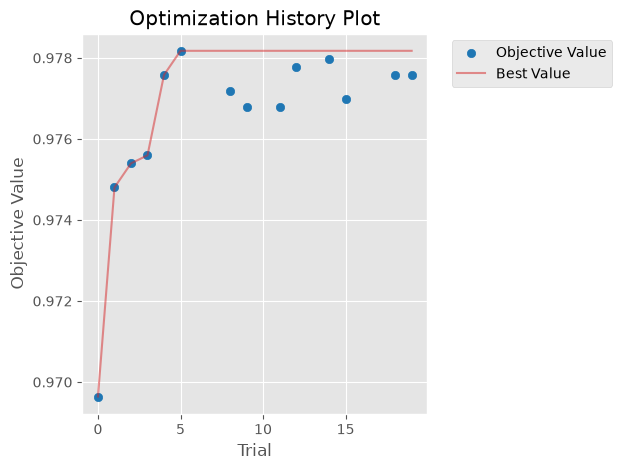

In [45]:
try:
    from optuna.visualization.matplotlib import plot_optimization_history

    ax = plot_optimization_history(study)
    plt.show()

except Exception as e:
    print("Optuna visualization could not be displayed:", e)

## Optuna Parameter Importance

This helps identify which hyperparameters had the strongest relationship with the objective during the study.

This is an analysis tool, not proof of causation.

C:\Users\Asim Shah\AppData\Local\Temp\ipykernel_1884\1053973446.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study)


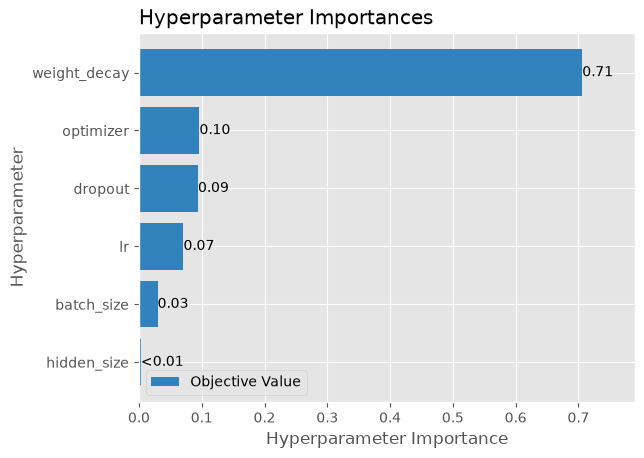

In [46]:
try:
    from optuna.visualization.matplotlib import plot_param_importances

    ax = plot_param_importances(study)
    plt.show()

except Exception as e:
    print("Optuna parameter-importance plot could not be displayed:", e)

# Part L: Train the Final Model

Now use the best hyperparameters discovered by Optuna.

**Important:** We still have not used the test set.

The test set will be used only after final training.

In [47]:
best_params = study.best_params

final_model = RegularizedMLP(
    hidden_size=best_params["hidden_size"],
    dropout=best_params["dropout"]
).to(device)

final_train_loader, final_val_loader = make_loaders(
    best_params["batch_size"]
)

if best_params["optimizer"] == "Adam":
    final_optimizer = torch.optim.Adam(
        final_model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )
else:
    final_optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )

final_criterion = nn.CrossEntropyLoss()

final_history = fit_model(
    final_model,
    final_train_loader,
    final_val_loader,
    final_criterion,
    final_optimizer,
    device,
    epochs=30,
    early_stopping=True,
    patience=5
)

Epoch 01/30 | Train Loss: 0.2667 | Train Acc: 0.9193 | Val Loss: 0.1383 | Val Acc: 0.9587
Epoch 02/30 | Train Loss: 0.1313 | Train Acc: 0.9609 | Val Loss: 0.1156 | Val Acc: 0.9637
Epoch 03/30 | Train Loss: 0.0950 | Train Acc: 0.9707 | Val Loss: 0.0939 | Val Acc: 0.9730
Epoch 04/30 | Train Loss: 0.0761 | Train Acc: 0.9764 | Val Loss: 0.1123 | Val Acc: 0.9688
Epoch 05/30 | Train Loss: 0.0628 | Train Acc: 0.9802 | Val Loss: 0.1120 | Val Acc: 0.9688
Epoch 06/30 | Train Loss: 0.0535 | Train Acc: 0.9829 | Val Loss: 0.1160 | Val Acc: 0.9679
Epoch 07/30 | Train Loss: 0.0526 | Train Acc: 0.9827 | Val Loss: 0.1007 | Val Acc: 0.9752
Epoch 08/30 | Train Loss: 0.0440 | Train Acc: 0.9858 | Val Loss: 0.0885 | Val Acc: 0.9782
Epoch 09/30 | Train Loss: 0.0373 | Train Acc: 0.9883 | Val Loss: 0.0940 | Val Acc: 0.9752
Epoch 10/30 | Train Loss: 0.0383 | Train Acc: 0.9880 | Val Loss: 0.0901 | Val Acc: 0.9788
Epoch 11/30 | Train Loss: 0.0326 | Train Acc: 0.9901 | Val Loss: 0.1001 | Val Acc: 0.9734
Epoch 12/3

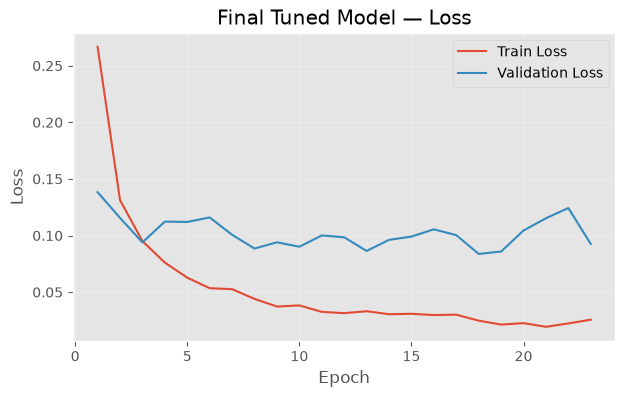

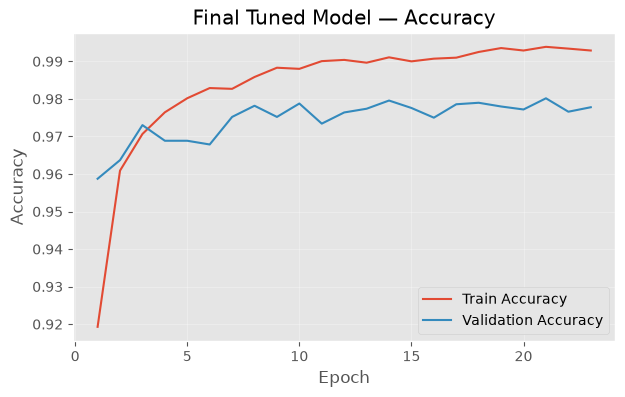

In [48]:
plot_history(final_history, "Final Tuned Model")

# Part M: Final Test Evaluation

This is the first time we evaluate the selected final model on the test set.

The test set was not used for:

- selecting regularization strength
- selecting learning rate
- selecting dropout
- selecting hidden size
- selecting batch size
- selecting optimizer

In [49]:
test_loss, test_acc = evaluate(
    final_model,
    test_loader,
    final_criterion,
    device
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.0861
Final Test Accuracy: 0.9795


## 6. Confusion Matrix

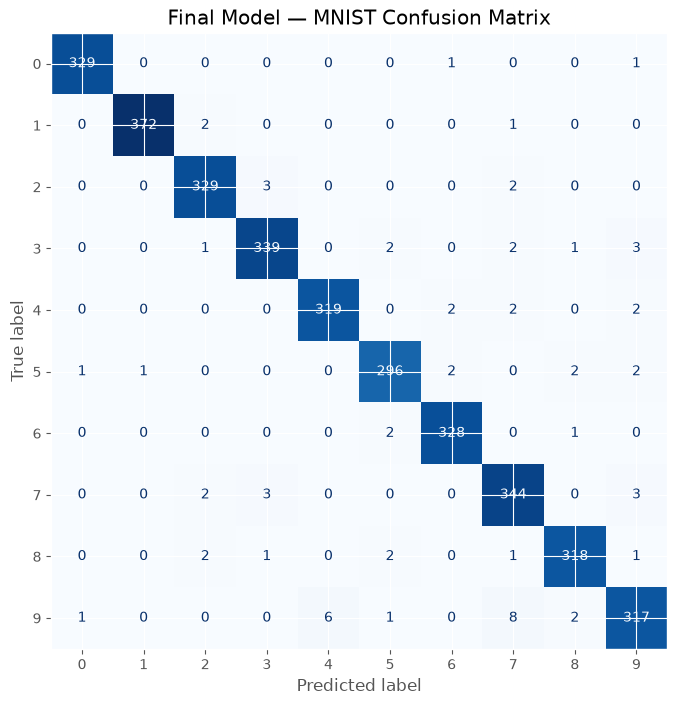

In [50]:
@torch.no_grad()
def get_predictions(model, loader, device):

    model.eval()

    all_predictions = []
    all_labels = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        outputs = model(X_batch)

        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_predictions.extend(predictions)
        all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_predictions)


y_true, y_pred = get_predictions(
    final_model,
    test_loader,
    device
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Final Model — MNIST Confusion Matrix")
plt.show()

## 7. Classification Report

In [51]:
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9940    0.9940    0.9940       331
           1     0.9973    0.9920    0.9947       375
           2     0.9792    0.9850    0.9821       334
           3     0.9798    0.9741    0.9769       348
           4     0.9815    0.9815    0.9815       325
           5     0.9769    0.9737    0.9753       304
           6     0.9850    0.9909    0.9880       331
           7     0.9556    0.9773    0.9663       352
           8     0.9815    0.9785    0.9800       325
           9     0.9635    0.9463    0.9548       335

    accuracy                         0.9795      3360
   macro avg     0.9794    0.9793    0.9794      3360
weighted avg     0.9795    0.9795    0.9795      3360



# Part N: Inspect Incorrect Predictions

A good DNN lab should not stop at accuracy.

Let's inspect examples that the model classified incorrectly.

In [52]:
wrong_indices = np.where(y_true != y_pred)[0]

print("Incorrect predictions:", len(wrong_indices))
print("Total test samples:", len(y_true))

Incorrect predictions: 69
Total test samples: 3360


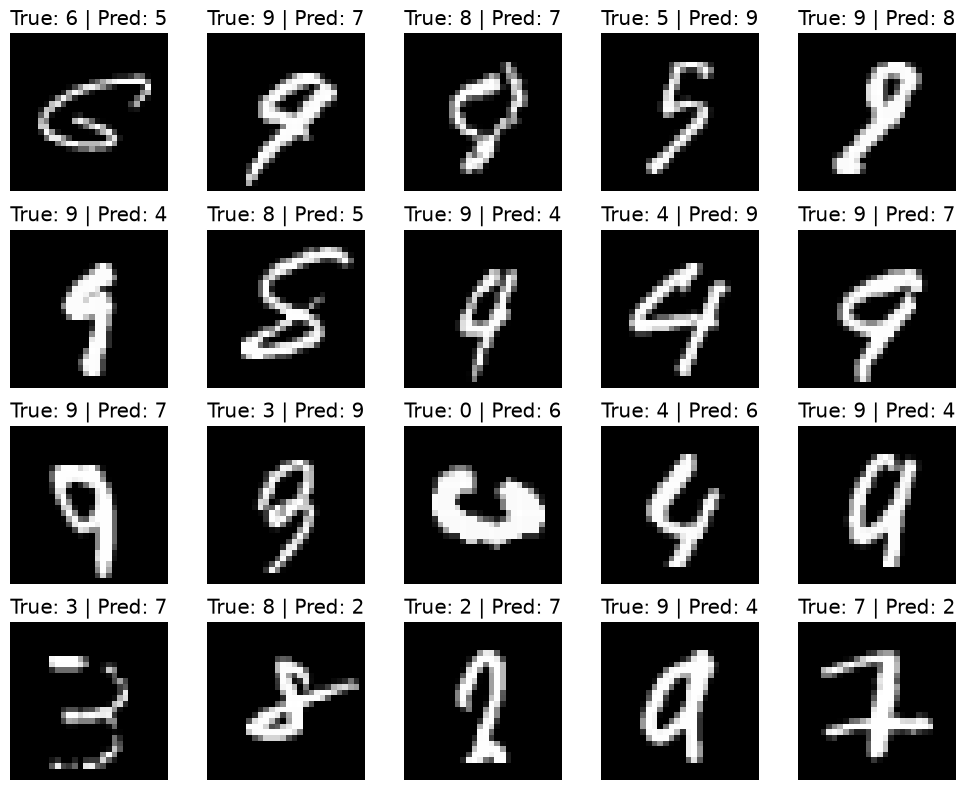

In [53]:
n_show = min(20, len(wrong_indices))

fig, axes = plt.subplots(
    4,
    5,
    figsize=(10, 8)
)

for ax, idx in zip(axes.flat, wrong_indices[:n_show]):

    image = X_test[idx].reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"True: {y_true[idx]} | Pred: {y_pred[idx]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# Part O: Final Experimental Comparison

Students should summarize their observations.

| Method | What changed? | Effect on training | Effect on validation |
|---|---|---|---|
| Baseline | No regularization | | |
| L1 | Absolute-weight penalty | | |
| L2 | Weight decay | | |
| Dropout | Random neuron deactivation | | |
| BatchNorm | Activation normalization | | |
| Early stopping | Stops based on validation loss | | |
| Combined | Multiple techniques | | |
| Optuna | Searches hyperparameters | | |

### Discussion

1. Which technique reduced the training/validation gap?
2. Did stronger regularization always improve validation accuracy?
3. What happened when dropout became too large?
4. Why should the test set not be used during tuning?
5. Why is Optuna more practical than a large Grid Search for many hyperparameters?

# Part P — Viva Questions

### Basic

1. What is overfitting?
2. What is underfitting?
3. What is regularization?
4. What is the difference between a parameter and a hyperparameter?
5. Why do we normalize MNIST pixels?
6. Why do we split the data into train, validation, and test sets?

### L1 / L2

7. Write the L1 regularization equation.
8. Write the L2 regularization equation.
9. What is weight decay?
10. What happens if the regularization coefficient is too large?
11. Why can L1 produce sparse weights?

### Dropout

12. What does Dropout do during training?
13. Does Dropout randomly remove neurons permanently?
14. What happens to Dropout during evaluation?
15. Why can excessive Dropout cause underfitting?

### BatchNorm

16. What does Batch Normalization normalize?
17. Is BatchNorm the same thing as Dropout?
18. Why does BatchNorm behave differently during training and evaluation?

### Early Stopping

19. Why monitor validation loss?
20. What is patience?
21. Why restore the best model state?

### Hyperparameter Tuning

22. What is Grid Search?
23. What is Random Search?
24. Why can Grid Search become expensive?
25. What is Optuna?
26. What is a trial in Optuna?
27. What is pruning?
28. Why does Optuna need a validation objective?
29. Why must the test set remain untouched during tuning?

### GPU

30. How do you check whether CUDA is available?
31. Why must both model and tensors be on the same device?
32. What does `non_blocking=True` mean?
33. Why can `pin_memory=True` help GPU training?

# Part Q — Practical Tasks

## Task 1 — Baseline
Train the baseline MLP and record:
- training accuracy
- validation accuracy
- training time

## Task 2 — L1
Try at least three L1 values:

```text
1e-7
1e-6
1e-5
```

Record validation accuracy.

## Task 3 — L2
Try:

```text
1e-5
1e-4
1e-3
```

Compare the results.

## Task 4 — Dropout
Try:

```text
0.1
0.3
0.5
```

Plot validation accuracy.

## Task 5 — Early Stopping
Change patience:

```text
2
3
5
```

Observe how many epochs are actually executed.

## Task 6 — Grid Search
Modify the grid and calculate how the number of experiments grows.

## Task 7 — Random Search
Run at least 10 random configurations.

## Task 8 — Optuna
Run:

```python
n_trials = 20
```

Then, if GPU time permits:

```python
n_trials = 50
```

Compare the best validation accuracy.

## Task 9 — Final Evaluation
Evaluate the final tuned model on the test set.

## Task 10 — Error Analysis
Display at least 20 incorrectly classified digits and explain two common confusion patterns.

# Submission Requirements

Submit the notebook containing:

1. Dataset inspection
2. GPU information
3. Train/validation/test split
4. Baseline model
5. Baseline loss/accuracy plots
6. L1 experiment
7. L2 experiment
8. Dropout experiment
9. BatchNorm experiment
10. Early stopping experiment
11. Regularization comparison table
12. Grid Search results
13. Random Search results
14. Optuna study
15. Best Optuna hyperparameters
16. Final training curves
17. Final test accuracy
18. Confusion matrix
19. Classification report
20. Incorrect prediction analysis
21. Answers to viva/discussion questions

### Final conclusion

Write a short conclusion answering:

> **How did regularization affect the DNN, and how did hyperparameter tuning improve the model-selection process?**

# End of Lab

### Core idea to remember

```text
Regularization
     ↓
Controls overfitting

Hyperparameter tuning
     ↓
Finds useful training/model configurations

Validation set
     ↓
Guides model selection

Test set
     ↓
Final unbiased evaluation
```

**PyTorch + GPU + Optuna** gives us a complete modern DNN training and optimization workflow.